In [52]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [13]:
customers_1_df = pd.read_csv("customers_1.csv")

In [14]:
products_df = pd.read_csv("products.csv")

In [15]:
sales_df = pd.read_csv("sales.csv")

In [16]:
customers_1_df.head()

,customer_id,first_name,last_name,age,state,income,registration_date,email
0,1,John,Smith,34,CA,75000,2022-01-15,john.smith@email.com
1,2,Sarah,Johnson,28,NY,82000,2022-01-22,sarah.johnson@email.com
2,3,Michael,Brown,45,TX,95000,2022-02-03,michael.brown@email.com
3,4,Emily,Davis,31,FL,68000,2022-02-14,emily.davis@email.com
4,5,David,Wilson,52,IL,110000,2022-02-28,david.wilson@email.com


In [17]:
products_df.head()

,product_id,product_name,category,price,launch_date,brand
0,1,Wireless Bluetooth Headphones,Electronics,79.99,2021-03-15,AudioTech
1,2,Organic Cotton T-Shirt,Clothing,24.99,2021-04-20,EcoWear
2,3,Stainless Steel Water Bottle,Home & Garden,19.99,2021-05-10,HydroLife
3,4,Leather Crossbody Bag,Accessories,89.99,2021-06-01,StyleCraft
4,5,Yoga Mat Premium,Sports & Outdoors,34.99,2021-06-15,FitZone


In [18]:
sales_df.head()

,sale_id,customer_id,product_id,transaction_date,quantity,total_amount
0,1,1,1,2022-02-10 14:30:00,1,79.99
1,2,2,3,2022-02-15 10:15:00,2,39.98
2,3,3,5,2022-02-20 16:45:00,1,34.99
3,4,4,2,2022-02-25 11:20:00,3,74.97
4,5,5,4,2022-03-01 13:10:00,1,89.99


In [ ]:
#Chart 1: Revenue by Product by Category

In [19]:
#1. Create a horizontal bar chart showing total revenue for each product category
category_revenue = products_df.groupby('category')['price'].sum().reset_index()

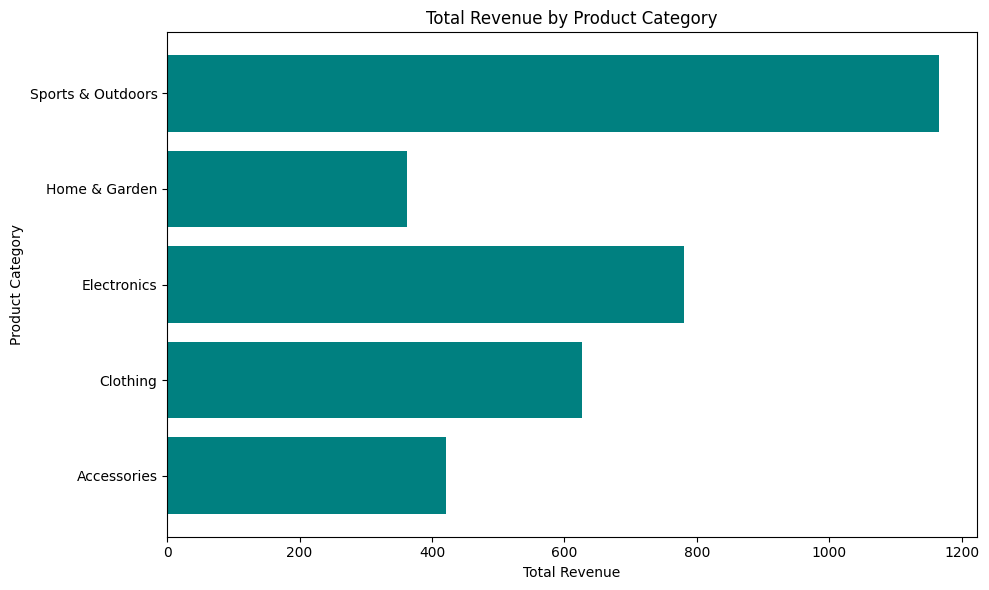

In [20]:
#Create the figure
plt.figure(figsize=(10, 6))

#Plot the horizontal bar chart
plt.barh(category_revenue['category'], category_revenue['price'], color='teal')

#Label the x-axis
plt.xlabel("Total Revenue")

#Label the y-axis
plt.ylabel("Product Category")

#Add a title
plt.title("Total Revenue by Product Category")

#Adjust layout for clean spacing
plt.tight_layout()

#Display the chart
plt.show()

In [22]:
#Group products by category and sum total revenue
category_revenue = products_df.groupby('category')['price'].sum().reset_index()

In [24]:
#Sort categories from highest to lowest revenue
category_revenue_sorted = category_revenue.sort_values(by='price', ascending=False)

In [26]:
#Sort categories from lowest to highest revenue
category_revenue_sorted = category_revenue.sort_values(by='price', ascending=True)

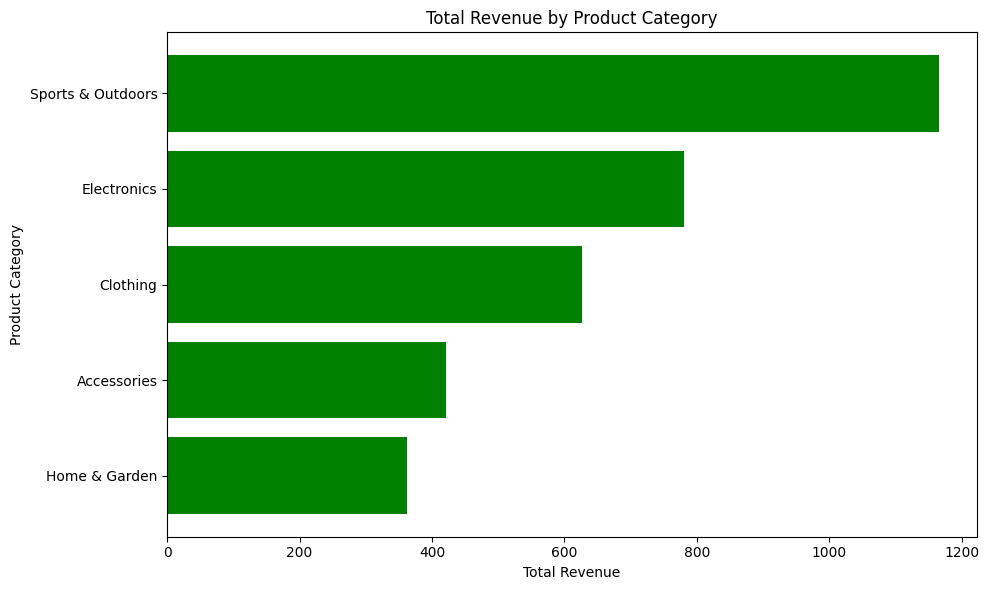

In [31]:
#2. Sort categories from highest to lowest revenue

#Create the figure
plt.figure(figsize=(10, 6))

#Plot the horizontal bar chart using sorted revenue
plt.barh(category_revenue_sorted['category'], category_revenue_sorted['price'], color='green')

#Label the x-axis
plt.xlabel("Total Revenue")

#Label the y-axis
plt.ylabel("Product Category")

#Add a title to the chart
plt.title("Total Revenue by Product Category")

#Adjust layout for clean spacing
plt.tight_layout()

#Display the chart
plt.show()


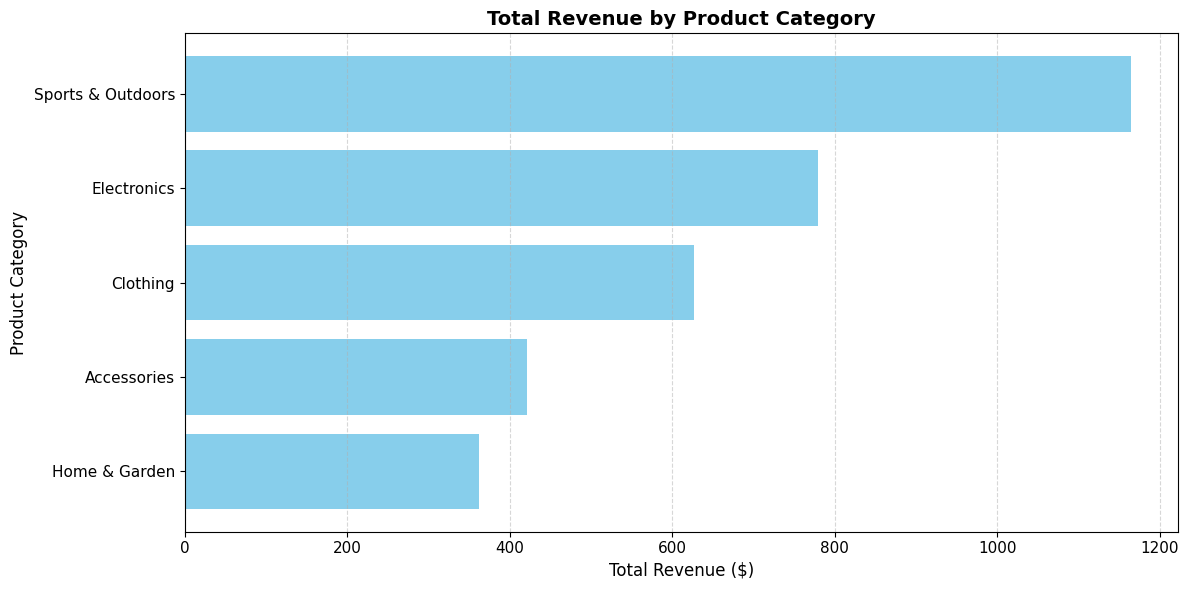

In [33]:
#3. Use clear, professional styling with proper labels

#Create the figure
plt.figure(figsize=(12, 6))

#Plot the horizontal bar chart using sorted revenue
plt.barh(category_revenue_sorted['category'], 
         category_revenue_sorted['price'], 
         color='skyblue')

#Label the x-axis
plt.xlabel("Total Revenue ($)", fontsize=12)

#Label the y-axis
plt.ylabel("Product Category", fontsize=12)

#Add a title to the chart
plt.title("Total Revenue by Product Category", fontsize=14, weight='bold')

#Adjust tick label sizes
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

#Add a simple grid for readability
plt.grid(axis='x', linestyle='--', alpha=0.5)

#Adjust layout for clean spacing
plt.tight_layout()

#Display the chart
plt.show()

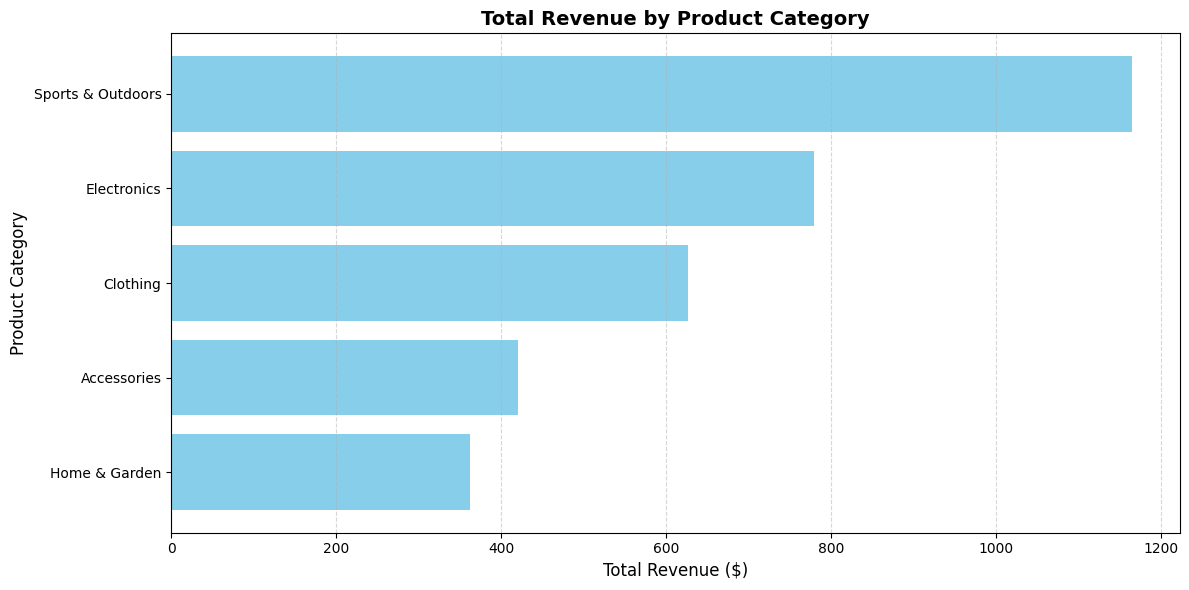

Revenue shown in US dollars ($)


In [38]:
#4. Format the x-axis to show currency values

#Create the figure
plt.figure(figsize=(12, 6))

#Plot the horizontal bar chart
plt.barh(category_revenue_sorted['category'],
         category_revenue_sorted['price'],
         color='skyblue')

#Label the x-axis
plt.xlabel("Total Revenue ($)", fontsize=12)

#Label the y-axis
plt.ylabel("Product Category", fontsize=12)

#Add a title
plt.title("Total Revenue by Product Category", fontsize=14, weight='bold')

#Add a light grid for readability
plt.grid(axis='x', linestyle='--', alpha=0.5)

#Adjust layout for clean spacing
plt.tight_layout()

#Dispaly the chart
plt.show()

#Print a simple note at the bottom of the chart
print("Revenue shown in US dollars ($)")

In [ ]:
#Chart 2: Customer Distribution by State

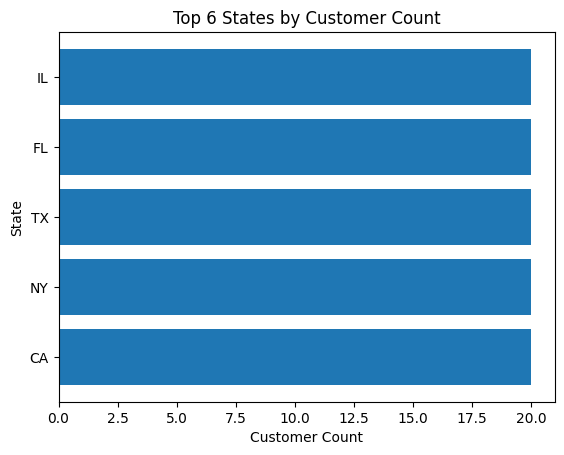

In [39]:
#Count customers by state and keep only the top 6
state_counts = customers_1_df['state'].value_counts().head(6)

#Plot the horizontal bar chart
plt.barh(state_counts.index, state_counts.values)

#Label the x-axis
plt.xlabel("Customer Count")

#Label the y-axis
plt.ylabel("State")

#Add a title
plt.title("Top 6 States by Customer Count")

#Display the chart
plt.show()


In [ ]:
#Chart 3: Daily Transaction Patterns

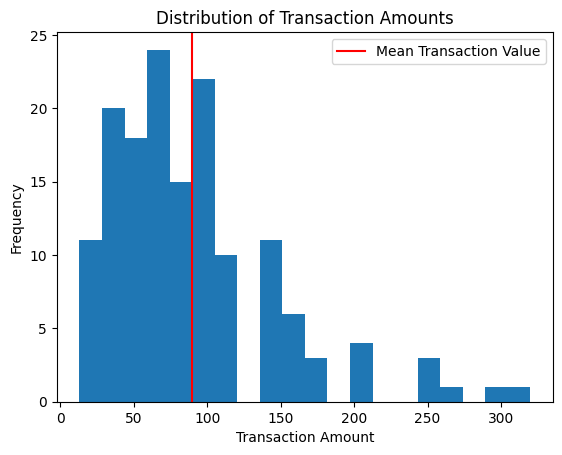

In [44]:
#Create the histogram of transaction amounts
plt.hist(sales_df['total_amount'], bins=20)

#Calculate the mean transaction value
mean_value = sales_df['total_amount'].mean()

#Add a vertical reference line for the mean
plt.axvline(mean_value, color='red', label='Mean Transaction Value')

#Label the x-axis
plt.xlabel("Transaction Amount")

#Label the y-axis
plt.ylabel("Frequency")

#Add a title
plt.title("Distribution of Transaction Amounts")

#Add a legend
plt.legend()

#Display the chart
plt.show()

In [ ]:
#Data Preparation Challenge:

In [45]:
#Group sales by customer and calculate total spending + purchase count
customer_sales = sales_df.groupby('customer_id')['total_amount'].agg(  
    #Sum all spending for each customer
    total_spending='sum',
    #Count number of purchases for each customer
    purchase_count='count'
# Convert grouped results into a clean dataframe    
).reset_index()


In [46]:
#Merge customer details with their spending summary
merged_df = customers_df.merge(customer_sales, on='customer_id', how='left')

In [47]:
#Replace missing total_spending values with 0 for customers with no purchases
merged_df['total_spending'] = merged_df['total_spending'].fillna(0)

#Replace missing purchase_count values with 0 for customers with no purchases
merged_df['purchase_count'] = merged_df['purchase_count'].fillna(0)

In [48]:
#Create age group categories using simple cut bins
merged_df['age_group'] = pd.cut(
    #Use the customer's age column
    merged_df['age'],
    #Define the age ranges (bins)
    bins=[0, 29, 45, 60, 200],
    #Assign labels to each age range
    labels=['Under 30', '30-45', '46-60', 'Over 60']
)

In [ ]:
#Layer 1: Foundation Scatter Plot

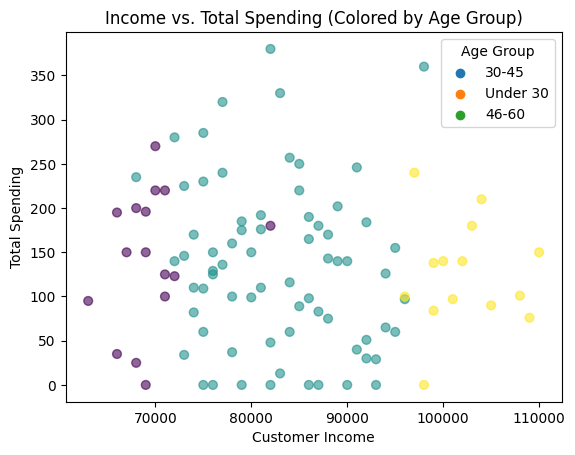

In [49]:
#Create the scatter plot
plt.scatter(
    merged_df['income'],
    merged_df['total_spending'],
    c=merged_df['age_group'].astype('category').cat.codes,  
    alpha=0.6,   
    s=40         
)

#Label the x-axis
plt.xlabel("Customer Income")

#Label the y-axis
plt.ylabel("Total Spending")

#Add a title
plt.title("Income vs. Total Spending (Colored by Age Group)")

#Create a simple legend for age groups
for group in merged_df['age_group'].unique():
    plt.scatter([], [], label=group)

#Display the legend
plt.legend(title="Age Group")

#Show the chart
plt.show()

In [ ]:
#Layer 2: Statistical Trend Analysis

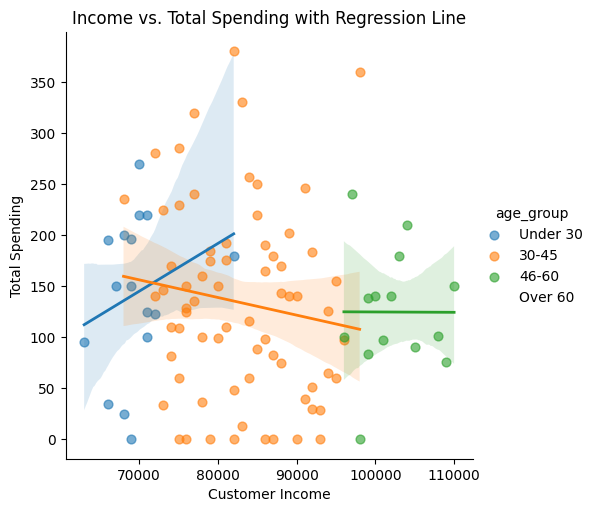

In [50]:
#Create scatter plot + regression line with confidence intervals
sns.lmplot(
    data=merged_df,
    x='income',
    y='total_spending',
    hue='age_group',      
    scatter_kws={'alpha': 0.6, 's': 40}, 
    line_kws={'linewidth': 2}             
)
#Label the x-axis
plt.xlabel("Customer Income")

#Label the y-axis
plt.ylabel("Total Spending")

#Add a title
plt.title("Income vs. Total Spending with Regression Line")

#Display the chart
plt.show()

In [ ]:
#Layer 3: Business Context References

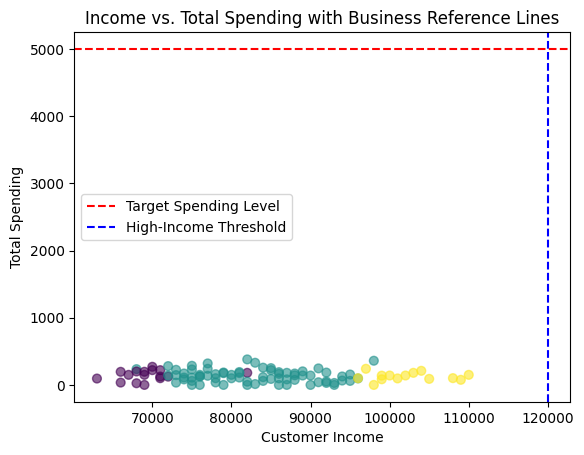

In [51]:
#Create the scatter plot
plt.scatter(
    merged_df['income'],
    merged_df['total_spending'],
    c=merged_df['age_group'].astype('category').cat.codes,
    alpha=0.6,
    s=40
)
#Define business reference values
#Spending target line
target_spending = 5000 
#High-income threshold line
high_income = 120000         

#Add horizontal reference line (spending target)
plt.axhline(
    target_spending,
    color='red',
    linestyle='--',
    label='Target Spending Level'
)
#Add vertical reference line (high-income threshold)
plt.axvline(
    high_income,
    color='blue',
    linestyle='--',
    label='High-Income Threshold'
)

#Label the x-axis
plt.xlabel("Customer Income")

#Label the y-axis
plt.ylabel("Total Spending")

#Add a title
plt.title("Income vs. Total Spending with Business Reference Lines")

#Add a legend
plt.legend()

#Display the chart
plt.show()

In [ ]:
#Layer 4: Statistical Annotations

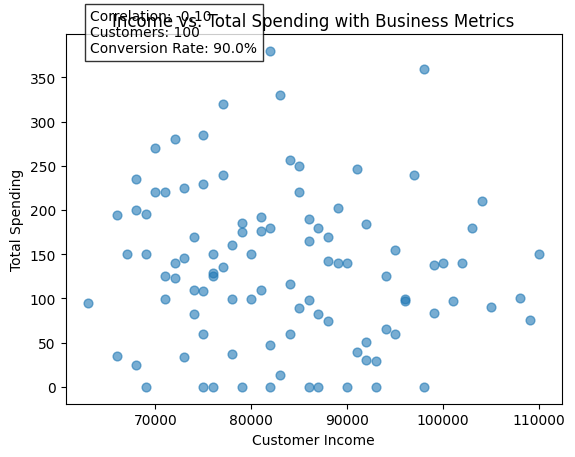

In [53]:
#Create the scatter plot
plt.scatter(
    merged_df['income'],
    merged_df['total_spending'],
    alpha=0.6,
    s=40
)

#Label the axes
plt.xlabel("Customer Income")
plt.ylabel("Total Spending")

#Add a title
plt.title("Income vs. Total Spending with Business Metrics")

#Calculate business metrics
corr = merged_df['income'].corr(merged_df['total_spending'])
customer_count = len(merged_df)
conversion_rate = (merged_df['purchase_count'] > 0).mean() * 100

#Build the annotation text
textstr = (
    f"Correlation: {corr:.2f}\n"
    f"Customers: {customer_count}\n"
    f"Conversion Rate: {conversion_rate:.1f}%"
)

#Add the annotation box
plt.annotate(
    textstr,
    xy=(0.05, 0.95),          
    xycoords='axes fraction',
    fontsize=10,
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
)

#Display the chart
plt.show()

In [ ]:
#Layer 5: Performance Insights

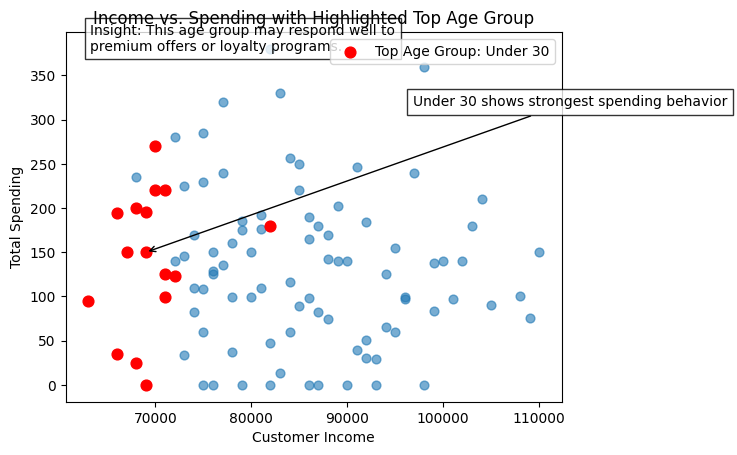

In [61]:
#Identify the age group with the highest average spending
top_group = merged_df.groupby('age_group')['total_spending'].mean().idxmax()

#Create the base scatter plot
plt.scatter(
    merged_df['income'],
    merged_df['total_spending'],
    alpha=0.6,
    s=40
)

#Filter data for the top-performing age group
highlight_df = merged_df[merged_df['age_group'] == top_group]

#Plot the highlighted age group in red
plt.scatter(
    highlight_df['income'],
    highlight_df['total_spending'],
    color='red',
    s=60,
    label=f"Top Age Group: {top_group}"
)

#Add an annotation pointing to the highlighted cluster
plt.annotate(
    f"{top_group} shows strongest spending behavior",
    xy=(highlight_df['income'].median(), highlight_df['total_spending'].median()),
    xytext=(0.7, 0.8),
    textcoords='axes fraction',
    arrowprops=dict(arrowstyle="->", color='black'),
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
)

#Add business insight annotation
plt.annotate(
    "Insight: This age group may respond well to\npremium offers or loyalty programs.",
    xy=(0.05, 0.95),
    xycoords='axes fraction',
    fontsize=10,
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
)

#Label axes
plt.xlabel("Customer Income")
plt.ylabel("Total Spending")

#Add a title
plt.title("Income vs. Spending with Highlighted Top Age Group")

#Add a legend
plt.legend()

#Display the chart
plt.show()
